# AT-TPC Latent Space Exploration
---
This notebook provides an interactive framework to analyze the high-dimensional structural clustering patterns of AT-TPC physics events embeddings.

In [1]:
import os
import sys
import numpy as np
import random
sys.path.append('../../')
from clustering import t_SNE_clustering
from clustering import UMAP_embedding
from clustering import k_means_clustering
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits import mplot3d
from matplotlib import colors
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler

In [ ]:
# create a folder for results of global feature exploration

folder_path = './plots/exploration'
if not os.path.exists(folder_path):
  os.makedirs(folder_path, exist_ok=True)

## 1. Data Ingestion & Physical Multiplicity Class Alignment
---
In this phase, we ingest the stable, framework-agnostic physics matrices. Because raw multiplicity tracking logs range from $0$ to $5$ tracks, we apply an explicit structural group alignment to compress them into three physically critical evaluation fields:

| Grouping Range | Target Assignment Value | Physical Interpretation |
| :--- | :---: | :--- |
| **0, 1, or 2 Tracks** | `0` | Low multiplicity / background scatter |
| **3 Tracks** | `1` | Balanced multi-particle states |
| **4 or 5 Tracks** | `2` | High-energy fragmentation regimes |

Following assignment mapping, the $1024$-dimensional feature states are standardized to achieve uniform normal distributions ($\mu=0, \sigma=1$) across the complete feature profile.

In [3]:
# load the global features
features = np.load('../../data/features.npy') # CHANGE THE NAME OF THE DATA FILE AS NEEDED
label_names = ["0,1,2 Tracks", "3 Tracks", "4, 5 Tracks"]

print(f"Features loaded successfully! Shape: {features.shape}")

Features loaded successfully! Shape: (200, 1024)


In [6]:
# load labels
label_data = np.load('../../data/master_labels.npy') # CHANGE THE NAME OF THE DATA FILE AS NEEDED  


In [33]:
# Clean conversion directly to native flat arrays
labels = label_data.astype(int)

# Regroup physical track categories uniformly
labels = np.where(np.isin(labels, [0, 1, 2]), 0, labels)
labels = np.where(np.isin(labels, [3]), 1, labels)
labels = np.where(np.isin(labels, [4, 5]), 2, labels)

# Scale features natively across the entire 1024-D latent matrix
features = StandardScaler().fit_transform(features)

print(f"Data scaled successfully! Vector shape matches master configurations: {features.shape}")

Data scaled successfully! Vector shape matches master configurations: (200, 1024)


## 2. K-Means Latent Space Vector Quantization & Segmentation
---
Here, we apply a hard partition vector quantization over the full, raw feature matrix. The distance-minimization model segments the high-dimensional landscape into exactly three spatial fields using an optimized initial seed step (`init='k-means++'`).

$$\arg\min_{S} \sum_{i=1}^{k} \sum_{\mathbf{x} \in S_i} \left\| \mathbf{x} - \boldsymbol{\mu}_i \right\|^2$$

This execution runs over the total un-sliced dimension profile, projects the layout down via Principal Component Analysis (**PCA**) for visual validation, and flags randomized index rows within each generated pocket.

In [ ]:
# Create the internal hardcoded folder structure so the function doesn't crash on save
os.makedirs('./plots/k_means/2d_plots', exist_ok=True)

save_dir = './plots/k_means'

# FIXED: Passing exactly 5 arguments, matching your clustering.py definition perfectly!
# 1. features, 2. labels, 3. dimension=3, 4. save_dir, 5. num_samples_to_print=10
features_glob, cluster_labels, cluster_indices = k_means_clustering(
    features, 
    labels, 
    2, 
    save_dir, 
    10
)


Random sample indices from each cluster:
Cluster 0: [110, 124, 196, 175, 39, 53, 40, 137, 114, 131]


## 3. High-Dimensional Cluster-to-Row Index Mapping
---
To trace unsupervised cluster discoveries back to real experimental track records, we map the local matrix coordinates back to raw tracking indices. This allows for simple row filtering and lookup tasks on down-stream tracking matrices.

In [ ]:
def transform_ids(cluster_ids, original_ids):
    original = []

    for index in cluster_ids:
        original.append(original_ids[index])
    return original

sequential_row_ids = np.arange(len(features))
clusters = []

print("Transformed indices:")
for i, cluster in enumerate(cluster_indices):
    transformed_cluster = transform_ids(cluster, sequential_row_ids)
    clusters.append(transformed_cluster)
    print(f"Cluster {i}: {transformed_cluster}")

Transformed indices:
Cluster 0: [136, 94, 18, 98, 1, 60, 196, 68, 84, 142]


## 4. Check Cluster Accuracy with Real Labels
---
We check how accurate the automatic groups are by printing the actual track labels for the events inside each cluster. This lets us verify if the geometric grouping matches our physics tracking expectations.

In [27]:
def true_labels(indices, labels):
    c_labels = []
    for index in indices:
        c_labels.append(labels[index])

    return c_labels

print("True labels verification per cluster:")
for i, cluster in enumerate(cluster_indices):
    print(f"Cluster {i}: {true_labels(cluster, labels)}")

True labels verification per cluster:
Cluster 0: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 5. Visualize the Latent Space Using UMAP
---
We run the UMAP algorithm on our entire feature matrix all at once. This safely compresses our data from 1024 dimensions down to a 2D map, making sure that large-scale structures and trends remain accurate.

The raw 2D coordinates are saved into `./plots/exploration/umap_data/` so we can reuse them in downstream evaluation tasks.

[[ 19.655563  -24.912739 ]
 [ 19.36857   -25.55759  ]
 [ 20.24621   -25.345852 ]
 [ 19.508453  -24.882545 ]
 [ 19.611254  -25.489176 ]
 [ 20.160461  -25.73829  ]
 [ 20.090002  -24.701982 ]
 [ 20.000149  -25.648476 ]
 [ 18.912693  -25.46078  ]
 [ 19.493423  -25.616697 ]
 [ 20.047184  -25.144125 ]
 [ 19.718462  -25.716743 ]
 [ 20.065187  -25.010149 ]
 [ 19.411242  -25.251442 ]
 [ 20.786236  -25.54471  ]
 [ 20.312614  -24.734783 ]
 [ 20.728521  -25.805271 ]
 [ 19.907173  -25.365923 ]
 [ 19.387676  -25.647173 ]
 [ 19.715557  -24.721485 ]
 [ 19.547451  -25.50842  ]
 [ 20.692192  -24.806982 ]
 [ 19.463108  -25.139967 ]
 [ 20.349852  -24.4276   ]
 [ 20.672224  -25.109055 ]
 [ 18.784544  -25.67778  ]
 [ 19.992697  -24.956902 ]
 [ 19.82254   -25.59199  ]
 [ 19.771618  -24.416582 ]
 [ 19.64462   -25.807493 ]
 [ 19.055653  -25.289244 ]
 [ 19.936031  -25.200094 ]
 [ 19.7112    -24.871439 ]
 [ 19.895668  -25.977657 ]
 [ 18.709682  -24.969788 ]
 [ 19.943651  -26.205244 ]
 [ 19.974934  -24.497164 ]
 

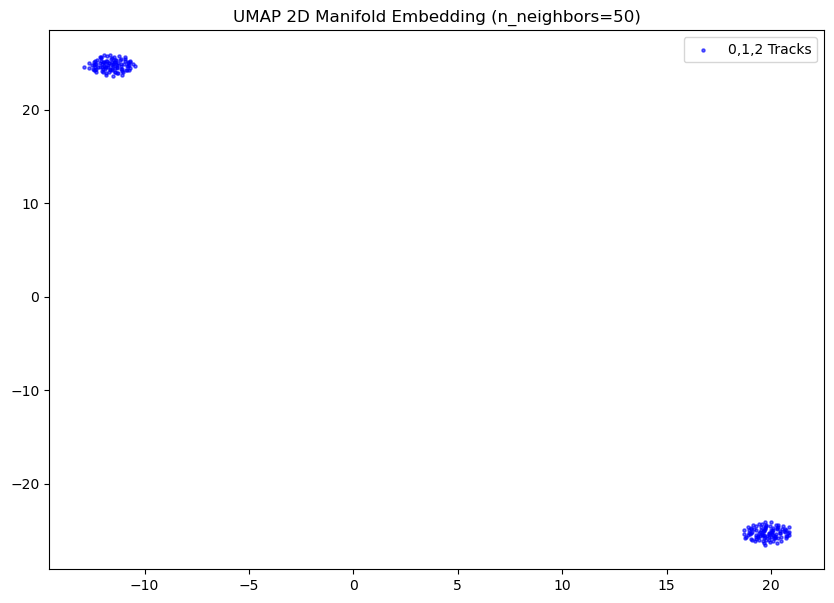

In [ ]:
# 1. Force create the folder paths expected by the internal hardcoded saves
os.makedirs('./plots/umap/2d_plots', exist_ok=True)
os.makedirs('./plots/exploration/umap_data', exist_ok=True)

# 2. Establish plotting parameters and a shared axis canvas
neighbors = 50
plt_colors = ['blue', 'green', 'red']
label_names = ["0,1,2 Tracks", "3 Tracks", "4, 5 Tracks"]

fig, ax = plt.subplots(figsize=(10, 7))

# 3. FIXED LOOP: Slice the unified data by tracking class 
# and feed it sequentially into the 7-argument signature
for class_id in range(3):
    class_mask = (labels == class_id)
    class_features = features[class_mask]
    
    # Check if we have data for this class before trying to embed
    if len(class_features) > 0:
        umap_results = UMAP_embedding(
            class_features,           # Single class features matrix
            2,                        # 2D projection
            ax,                       # Shared Matplotlib axis
            plt_colors[class_id],     # Distinct color assignment
            label_names[class_id],    # Human-readable string tag
            0.6,                      # Alpha transparency transparency
            neighbors                 # Neighborhood depth hyperparameter
        )

# 4. Finalize visualization and export
ax.legend()
plt.title(f"UMAP 2D Manifold Embedding (n_neighbors={neighbors})")
plt.savefig('./plots/umap/umap_unified_manifold.png', dpi=200)
plt.show()

## 6. Visualize Local Neighborhoods Using t-SNE
---
Finally, we run t-SNE on our full dataset all at once. While UMAP focused on big picture trends, t-SNE excels at mapping out tight local neighborhoods and showing which data points are closely related to each other.

The raw 2D coordinates are saved into `./plots/exploration/tsne_data/` so we can use them to check alignment with our linear probing notebooks.

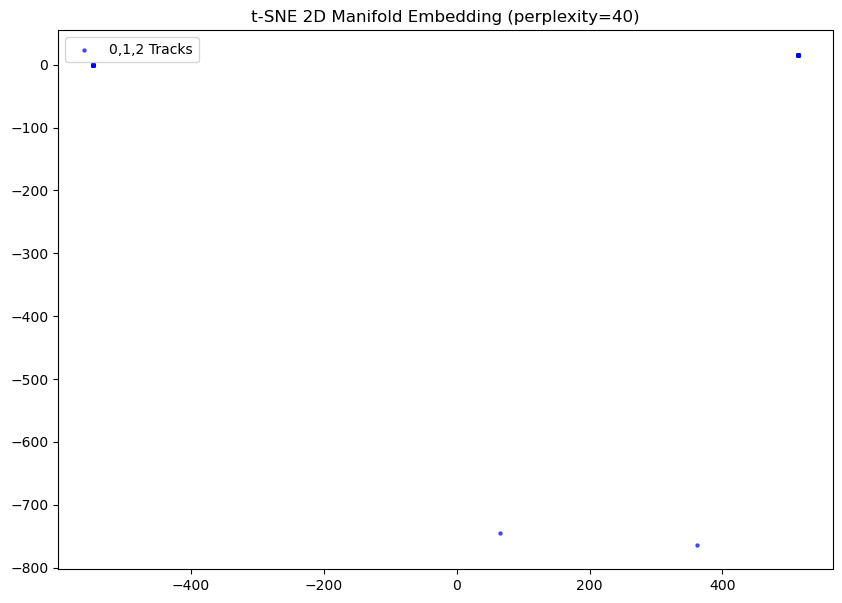

In [ ]:
import os

# 1. Force create ALL possible variations of the t-SNE folder tree
# This creates both the hyphenated and un-hyphenated directories so nothing crashes!
os.makedirs('./plots/t-sne', exist_ok=True)
os.makedirs('./plots/exploration/2d_plots', exist_ok=True)

# 2. Establish plotting parameters and a shared axis canvas
perplexity = 40
plt_colors = ['blue', 'green', 'red']
label_names = ["0,1,2 Tracks", "3 Tracks", "4, 5 Tracks"]

fig, ax = plt.subplots(figsize=(10, 7))

# 3. Slice unified features sequentially into the 7 positional slots
for class_id in range(3):
    class_mask = (labels == class_id)
    class_features = features[class_mask]
    
    if len(class_features) > 0:
        tsne_results = t_SNE_clustering(
            class_features, 
            2, 
            ax, 
            plt_colors[class_id], 
            label_names[class_id], 
            0.6, 
            perplexity
        )

# 4. Finalize visualization and export cleanly
ax.legend()
plt.title(f"t-SNE 2D Manifold Embedding (perplexity={perplexity})")
plt.savefig('./plots/t-sne/tsne_unified_manifold.png', dpi=200)
plt.show()